# import library

In [1]:
!pip uninstall -y transformers tensorflow-text
!pip install -q transformers tensorflow-text Sastrawi pandarallel jax jaxlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, nltk

# TensorFlow & Transformers
import tensorflow as tf
import tensorflow_text as tf_text
from tensorflow.keras.layers import TextVectorization

# NLP Tools
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from pandarallel import pandarallel

# Download resource NLTK (Hanya sekali)
nltk.download('stopwords')
nltk.download('punkt')

# Inisialisasi Pandarallel untuk proses paralel (mempercepat preprocessing)
pandarallel.initialize(progress_bar=True)

# Inisialisasi Stemmer secara GLOBAL agar tidak dipanggil berulang kali
factory = StemmerFactory()
stemmer = factory.create_stemmer()
list_stopwords = set(stopwords.words('indonesian'))


Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: tensorflow-text 2.20.1
Uninstalling tensorflow-text-2.20.1:
  Successfully uninstalled tensorflow-text-2.20.1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 12.7 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


INFO: Pandarallel will run on 1 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [2]:
#file requirements.txt dari pip freeze
!pip freeze > requirements.txt
#menampilkan beberapa baris awal untuk verifikasi
!head -n 40 requirements.txt

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.5
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.53.0.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.4.20.0.58.15
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.6.11
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6


In [74]:
from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# loading dataset (llm 25k + epo 6k)

In [3]:
import pandas as pd

# --- BAGIAN 1: Load Dataset EPO ---
anger_url = 'https://raw.githubusercontent.com/Ricco48/Emotion-Dataset-from-Indonesian-Public-Opinion/refs/heads/main/Emotion%20Dataset%20from%20Indonesian%20Public%20Opinion/AngerData.csv'
fear_url = 'https://raw.githubusercontent.com/Ricco48/Emotion-Dataset-from-Indonesian-Public-Opinion/refs/heads/main/Emotion%20Dataset%20from%20Indonesian%20Public%20Opinion/FearData.csv'
joy_url = 'https://raw.githubusercontent.com/Ricco48/Emotion-Dataset-from-Indonesian-Public-Opinion/refs/heads/main/Emotion%20Dataset%20from%20Indonesian%20Public%20Opinion/JoyData.csv'
sad_url = 'https://raw.githubusercontent.com/Ricco48/Emotion-Dataset-from-Indonesian-Public-Opinion/refs/heads/main/Emotion%20Dataset%20from%20Indonesian%20Public%20Opinion/SadData.csv'
neutral_url = 'https://raw.githubusercontent.com/Ricco48/Emotion-Dataset-from-Indonesian-Public-Opinion/refs/heads/main/Emotion%20Dataset%20from%20Indonesian%20Public%20Opinion/NeutralData.csv'

df_anger = pd.read_csv(anger_url, sep='\t')
df_fear = pd.read_csv(fear_url, sep='\t')
df_joy = pd.read_csv(joy_url, sep='\t')
df_sad = pd.read_csv(sad_url, sep='\t')
df_neutral = pd.read_csv(neutral_url, sep='\t')

# Gabungkan EPO
df_epo = pd.concat([df_anger, df_fear, df_joy, df_sad, df_neutral], ignore_index=True)
df_epo['Label'] = df_epo['Label'].str.lower()

# --- BAGIAN 2: Load Dataset Raw (Diverse Emotion) ---
url = 'https://raw.githubusercontent.com/putsiput/new-nlp-dataset/refs/heads/main/diverse_emotion_dataset_50k.csv'
df = pd.read_csv(url)

# --- BAGIAN 3: Sampling & Penggabungan ---
# Ambil 25.000 dari dataset diverse
df_subset = df.sample(n=25000, random_state=42)

# Samakan nama kolom df_epo agar sesuai dengan df_subset
# Kita ubah 'tweet' -> 'text' dan 'Label' -> 'emotion_label'
df_epo = df_epo.rename(columns={
    'Tweet': 'text',
    'Label': 'emotion_label'
})

# Pastikan kolom di df_subset juga menggunakan nama yang sama (opsional, untuk memastikan)
# Jika df_subset sudah punya kolom 'text' dan 'emotion_label', langkah ini hanya mempertegas.
df_subset = df_subset[['text', 'emotion_label']]

# Gabungkan df_epo dengan data llm tadi
# Karena nama kolom sudah sama, mereka akan otomatis masuk ke kolom yang sama
df_final = pd.concat([df_epo, df_subset], ignore_index=True)


# --- BAGIAN 4: Penyeragaman Label Emosi ---

# Pastikan semua teks label dalam huruf kecil dan tanpa spasi tambahan
df_final['emotion_label'] = df_final['emotion_label'].str.lower().str.strip()

# Kamus pemetaan (mapping) untuk menyamakan makna yang sama
# Silakan sesuaikan mapping ini berdasarkan isi unik dataset Anda
label_mapping = {
    'anger': 'angry',
    'joy': 'happy',
    'sadness': 'sad',
    'fear': 'fear',
    'love': 'happy',      # Opsional: menggabung love ke happy
    'neutral': 'neutral'
}

df_final['emotion_label'] = df_final['emotion_label'].replace(label_mapping)

# --- BAGIAN 5: Verifikasi Hasil ---
print(f"Jumlah baris df_epo: {len(df_epo)}")
print(f"Jumlah baris df_subset: {len(df_subset)}")
print(f"Total baris df_final: {len(df_final)}")
print("-" * 30)
print("Kolom Akhir:", df_final.columns.tolist())
print("\nDistribusi Label Akhir:")
print(df_final['emotion_label'].value_counts())

# Tampilkan 5 baris pertama
df_final.head()

Jumlah baris df_epo: 6320
Jumlah baris df_subset: 25000
Total baris df_final: 31320
------------------------------
Kolom Akhir: ['text', 'emotion_label']

Distribusi Label Akhir:
emotion_label
neutral    6998
happy      6282
angry      6121
fear       5971
sad        5948
Name: count, dtype: int64


,text,emotion_label
0,pagi2 udah di buat emosi :),angry
1,"kok stabilitas negara, memange 10 thn negara t...",angry
2,dah lah emosi mulu liat emyu,angry
3,"aib? bodoh benar! sebelum kata aib itu muncul,...",angry
4,dih lu yg nyebelin bego,angry


In [4]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df_final)

https://docs.google.com/spreadsheets/d/1LMQZ_jCY3sW9UeuXEQ8J6zRVKf4EhHuOgXihKGWgBk8/edit#gid=0


In [5]:
# Menampilkan informasi tentang DataFrame clean_df setelah membersihkan nilai yang hilang (NaN)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31320 entries, 0 to 31319
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           31320 non-null  object
 1   emotion_label  31320 non-null  object
dtypes: object(2)
memory usage: 489.5+ KB


# **Pre Processing Text**

1. `cleaningText(text)`: Fungsi ini digunakan untuk membersihkan teks dengan beberapa langkah, seperti menghapus mention, hashtag, RT (retweet), tautan (link), angka, dan tanda baca. Selain itu, itu juga menggantikan karakter newline dengan spasi dan menghilangkan spasi ekstra di awal dan akhir teks.

2. `casefoldingText(text)`: Fungsi ini mengonversi semua karakter dalam teks menjadi huruf kecil (lowercase), sehingga teks menjadi lebih seragam.

3. `tokenizingText(text)`: Fungsi ini digunakan untuk membagi teks menjadi daftar kata atau token. Ini berguna untuk mengurai teks menjadi komponen-komponen dasar.

4. `filteringText(text)`: Fungsi ini digunakan untuk menghapus kata-kata berhenti (stopwords) dalam teks. Anda telah memperbarui daftar kata-kata berhenti dengan beberapa kata tambahan.

5. `stemmingText(text)`: Fungsi ini menerapkan stemming pada teks, yaitu mengurangi kata-kata menjadi bentuk dasarnya. Anda menggunakan pustaka Sastrawi untuk melakukan stemming dalam bahasa Indonesia.

6. `toSentence(list_words)`: Fungsi ini digunakan untuk menggabungkan daftar kata-kata menjadi sebuah kalimat.

In [6]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # remove mentions
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # remove hashtag
    text = re.sub(r'RT[\s]', '', text) # remove RT
    text = re.sub(r"http\S+", '', text) # remove link
    text = re.sub(r'[0-9]+', '', text) # remove numbers
    text = re.sub(r'[^\w\s]', '', text) # remove numbers


    text = text.replace('\n', ' ') # replace new line into space
    text = text.translate(str.maketrans('', '', string.punctuation)) # remove all punctuations
    text = text.strip(' ') # remove characters space from both left and right text
    return text

def casefoldingText(text): # Converting all the characters in a text into lower case
    text = text.lower()
    return text

def tokenizingText(text): # Tokenizing or splitting a string, text into a list of tokens
    text = word_tokenize(text)
    return text

def filteringText(text): # Remove stopwors in a text
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text): # Reducing a word to its word stem that affixes to suffixes and prefixes or to the roots of words
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    # Memecah teks menjadi daftar kata
    words = text.split()

    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]

    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

    return stemmed_text
def toSentence(list_words): # Convert list of words into sentence
    sentence = ' '.join(word for word in list_words)
    return sentence

In [7]:
import requests
import json

# ambil file dari GitHub
url_slang = "https://raw.githubusercontent.com/louisowen6/NLP_bahasa_resources/master/combined_slang_words.txt"
response_slang = requests.get(url_slang)
raw = response_slang.text

# mengubah data teks python menjadi dict Python
slangwords = json.loads(raw)

# fungsi untuk mengatasi kata slang berdasarkan file yang diimpor dari github
def fix_slangwords(text):
    words = text.split() # memecah kata berdasarkan spasi
    fixed = [slangwords.get(w.lower(), w) for w in words] # mencari kata dalam slangwords. jika ada ambil arti bakunya dan jika tidak pakai kata aslinya
    return ' '.join(fixed)

In [8]:
#uji coba kamus slang
contoh = "bete bgt gw"
print("Sebelum:", contoh)
print("Sesudah:", fix_slangwords(contoh))

Sebelum: bete bgt gw
Sesudah: bosan banget saya


In [9]:
df_final

,text,emotion_label
0,pagi2 udah di buat emosi :),angry
1,"kok stabilitas negara, memange 10 thn negara t...",angry
2,dah lah emosi mulu liat emyu,angry
3,"aib? bodoh benar! sebelum kata aib itu muncul,...",angry
4,dih lu yg nyebelin bego,angry
...,...,...
31315,Sekarang lagi takut pas takut mengecewakan tim...,fear
31316,Hari ini pas beresin kamar,neutral
31317,Untung aja karena berhasil deploy aplikasi aku...,happy
31318,Akhirnya nilai revisi naik,happy


In [11]:
import nltk
nltk.download('punkt_tab', quiet=True)

# Membersihkan teks dan menyimpannya di kolom 'text_clean'
df_final['text_clean'] = df_final['text'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
df_final['text_casefoldingText'] = df_final['text'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
df_final['text_slangwords'] = df_final['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
df_final['text_tokenizingText'] = df_final['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
df_final['text_stopword'] = df_final['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
df_final['text_akhir'] = df_final['text_stopword'].apply(toSentence)

In [12]:
df_final.head()

,text,emotion_label,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,pagi2 udah di buat emosi :),angry,pagi udah di buat emosi,pagi2 udah di buat emosi :),pagi2 sudah di buat emosi :),"[pagi2, sudah, di, buat, emosi, :, )]","[pagi2, emosi, :, )]",pagi2 emosi : )
1,"kok stabilitas negara, memange 10 thn negara t...",angry,kok stabilitas negara memange thn negara tdk ...,"kok stabilitas negara, memange 10 thn negara t...","kok stabilitas negara, memange 10 tahun negara...","[kok, stabilitas, negara, ,, memange, 10, tahu...","[stabilitas, negara, ,, memange, 10, negara, a...","stabilitas negara , memange 10 negara aman , s..."
2,dah lah emosi mulu liat emyu,angry,dah lah emosi mulu liat emyu,dah lah emosi mulu liat emyu,deh lah emosi melulu lihat emyu,"[deh, lah, emosi, melulu, lihat, emyu]","[deh, emosi, melulu, lihat, emyu]",deh emosi melulu lihat emyu
3,"aib? bodoh benar! sebelum kata aib itu muncul,...",angry,aib bodoh benar sebelum kata aib itu muncul te...,"aib? bodoh benar! sebelum kata aib itu muncul,...","aib? bodoh benar! sebelum kata aib itu muncul,...","[aib, ?, bodoh, benar, !, sebelum, kata, aib, ...","[aib, ?, bodoh, !, aib, muncul, ,, tindakan, ....","aib ? bodoh ! aib muncul , tindakan . kekejian..."
4,dih lu yg nyebelin bego,angry,dih lu yg nyebelin bego,dih lu yg nyebelin bego,dih kamu yang nyebelin bego,"[dih, kamu, yang, nyebelin, bego]","[dih, nyebelin, bego]",dih nyebelin bego


# Custom Classes (attention layer, weighted loss, callback)

In [13]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Dense, Embedding, Bidirectional, LSTM, Dropout
import time
import datetime
import numpy as np
from sklearn.utils import class_weight

# ==========================================
# 1. Implementasi AttentionLayer
# ==========================================
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='att_weight', shape=(input_shape[-1], input_shape[-1]),
                                 initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(name='att_bias', shape=(input_shape[-1],),
                                 initializer='zeros', trainable=True)
        self.V = self.add_weight(name='att_context_vector', shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform', trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        u = tf.tanh(tf.einsum('btd,df->btf', inputs, self.W) + self.b)
        scores = tf.einsum('btf,fk->btk', u, self.V)
        alpha = tf.nn.softmax(scores, axis=1)
        context_vector = tf.reduce_sum(inputs * alpha, axis=1)
        return context_vector

# ==========================================
# 2. Implementasi WeightedFocalLoss
# ==========================================
class WeightedFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, class_weights=None, name='weighted_focal_loss'):
        super().__init__(name=name)
        self.gamma = gamma
        self.alpha = alpha
        self.class_weights = class_weights

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, dtype=tf.int32)
        y_pred = tf.cast(y_pred, dtype=tf.float32)

        if y_true.shape.ndims == y_pred.shape.ndims - 1:
            y_true = tf.one_hot(y_true, depth=y_pred.shape[-1])

        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        cross_entropy = -y_true * tf.math.log(y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - self.alpha)
        alpha_factor = y_true * self.alpha + (1 - y_true) * (1 - self.alpha)

        if self.class_weights is not None:
            # Pastikan class_weights dalam bentuk list/tensor yang urut sesuai indeks kelas
            weights_list = [self.class_weights[i] for i in range(len(self.class_weights))]
            weights_tensor = tf.gather(tf.constant(weights_list, dtype=tf.float32), tf.argmax(y_true, axis=-1))
            alpha_factor = alpha_factor * tf.expand_dims(weights_tensor, axis=-1)

        focal_loss = alpha_factor * tf.math.pow((1. - p_t), self.gamma) * cross_entropy
        return tf.reduce_sum(focal_loss, axis=-1)

# ==========================================
# 3. Implementasi VitaraTrainingLogger
# ==========================================
class VitaraTrainingLogger(tf.keras.callbacks.Callback):
    def __init__(self, log_dir, optimizer, **kwargs):
        super(VitaraTrainingLogger, self).__init__(**kwargs)
        self.log_dir = log_dir
        self.optimizer = optimizer
        self.writer = tf.summary.create_file_writer(log_dir)
        self.train_start_time = None
        self.epoch_start_time = None

    def on_train_begin(self, logs=None):
        self.train_start_time = time.time()
        print("="*80)
        wib_tz = datetime.timezone(datetime.timedelta(hours=7))
        start_time_str = datetime.datetime.now(wib_tz).strftime('%Y-%m-%d %H:%M:%S WIB')
        print(f"🚀 [Vitara AI] Training Started at {start_time_str}")
        print(f"Log Directory: {self.log_dir}")
        print("="*80)

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        epoch_time = time.time() - self.epoch_start_time
        # Filter logs untuk menampilkan loss dan accuracy saja agar rapi
        metrics_str = " | ".join([f"{k}: {v:.4f}" for k, v in logs.items()])
        print(f"Epoch {epoch + 1:03d} | {epoch_time:.1f}s | {metrics_str}")

        with self.writer.as_default():
            for key, value in logs.items():
                tf.summary.scalar(f'epoch/{key}', value, step=epoch)
            tf.summary.scalar('epoch/learning_rate', self.optimizer.learning_rate.numpy(), step=epoch)
        self.writer.flush()

    def on_train_end(self, logs=None):
        total_time = time.time() - self.train_start_time
        hours, rem = divmod(total_time, 3600)
        minutes, seconds = divmod(rem, 60)
        print("="*80)
        print(f"✅ [Vitara AI] Training Completed in {int(hours):02d}:{int(minutes):02d}:{seconds:.1f}")
        print("="*80)
        self.writer.close()

print("Semua komponen kustom Vitara AI berhasil didefinisikan!")

Semua komponen kustom Vitara AI berhasil didefinisikan!


In [14]:
# Hitung bobot
weights = class_weight.compute_class_weight('balanced', classes=np.unique(df_final['emotion_label']), y=df_final['emotion_label'])
class_weights_dict = {i: w for i, w in enumerate(weights)}

# Inisialisasi Komponen
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
opt = tf.keras.optimizers.Adam(learning_rate=1e-3)
loss_fn = WeightedFocalLoss(class_weights=class_weights_dict)
logger = VitaraTrainingLogger(log_dir=log_dir, optimizer=opt)


In [15]:
# label encoder dari kolom emotion_label >> emotion_id

from sklearn.preprocessing import LabelEncoder

# Asumsikan kolom label asli bernama 'emotion_label'
column_name = 'emotion_label'

le = LabelEncoder()
df_final['emotion_id'] = le.fit_transform(df_final[column_name])

# Melihat hasil mapping (misal: 0 = anger, 1 = joy, dst)
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapping Label:", mapping)

Mapping Label: {'angry': np.int64(0), 'fear': np.int64(1), 'happy': np.int64(2), 'neutral': np.int64(3), 'sad': np.int64(4)}


# Data Splitting

In [16]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Pembagian Pertama: Sisihkan 60% untuk Train, 40% sisanya untuk (Val + Test)
df_final_train, df_final_temp = train_test_split(
    df_final,
    test_size=0.40,
    random_state=42,
    stratify=df_final['emotion_id'] # Menjaga proporsi emosi
)

# Pembagian Kedua: Bagi 40% sisa tadi menjadi dua bagian sama besar (20% Val, 20% Test)
# test_size=0.5 dari 40% adalah 20% dari total data awal
df_final_val, df_final_test = train_test_split(
    df_final_temp,
    test_size=0.50,
    random_state=42,
    stratify=df_final_temp['emotion_id']
)

# 3. Verifikasi Jumlah Data
print(f"Jumlah Data Train: {len(df_final_train)} (60%)")
print(f"Jumlah Data Val:   {len(df_final_val)} (20%)")
print(f"Jumlah Data Test:  {len(df_final_test)} (20%)")

# 4. Simpan ke dalam format CSV
df_final_train.to_csv('train_data.csv', index=False)
df_final_val.to_csv('val_data.csv', index=False)
df_final_test.to_csv('test_data.csv', index=False)

print("\nDataset berhasil disimpan ke format CSV!")

Jumlah Data Train: 18792 (60%)
Jumlah Data Val:   6264 (20%)
Jumlah Data Test:  6264 (20%)

Dataset berhasil disimpan ke format CSV!


# tensorboard

In [46]:
%load_ext tensorboard

# model building

In [17]:
#jembatan

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Parameter
max_words = 10000  # Gunakan 10rb kata paling populer
max_len = 100      # Maksimal 100 kata per kalimat

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df_final['text']) # nama kolom teks


# Koreksi sedikit: pastikan menggunakan dataframe yang benar (df_final)
sequences = tokenizer.texts_to_sequences(df_final['text'])
X = pad_sequences(sequences, maxlen=max_len, padding='post')
y = df_final['emotion_id'].values

In [18]:
# membangun arsitektur model

embedding_dim = 128
num_classes = len(np.unique(y))

model = tf.keras.Sequential([
    # Layer Input/Embedding
    Embedding(max_words, embedding_dim, input_length=max_len),

    # Layer BiLSTM (Penting: return_sequences=True agar Attention bisa bekerja)
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),

    # Custom Attention Layer Anda
    AttentionLayer(),

    # Dense Layer & Output
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [19]:
import tensorflow as tf

# 1. Persiapan data training dan validasi
X_train_raw = df_final_train['text_akhir']
y_train = df_final_train['emotion_id'].values
sequences_train = tokenizer.texts_to_sequences(X_train_raw)
X_train = pad_sequences(sequences_train, maxlen=max_len, padding='post')

X_val_raw = df_final_val['text_akhir']
y_val = df_final_val['emotion_id'].values
sequences_val = tokenizer.texts_to_sequences(X_val_raw)
X_val = pad_sequences(sequences_val, maxlen=max_len, padding='post')

# 2. Inisialisasi Optimizer & Loss
initial_lr = 1e-3
opt = tf.keras.optimizers.Adam(learning_rate=initial_lr)
loss_fn = WeightedFocalLoss(class_weights=class_weights_dict)

# 3. Konversi ke Dataset TF
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1024).batch(32)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(32)

# 4. Metrik
train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
val_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()

# 5. Parameter Penurun Learning Rate (Manual ReduceLROnPlateau)
wait = 0
patience = 3
best_val_acc = 0.0
lr_factor = 0.5  # Faktor pengali (turun 50%)

@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        logits = model(x, training=True)
        loss_value = loss_fn(y, logits)
    grads = tape.gradient(loss_value, model.trainable_weights)
    opt.apply_gradients(zip(grads, model.trainable_weights))
    train_acc_metric.update_state(y, logits)
    return loss_value

# 6. Eksekusi Loop Pelatihan Manual
for epoch in range(20):
    print(f"\nMemulai Epoch {epoch + 1}")

    # Training Loop
    for x_batch, y_batch in train_dataset:
        loss = train_step(x_batch, y_batch)

    # Validation Loop (Manual)
    for x_val, y_val in val_dataset:
        val_logits = model(x_val, training=False)
        val_acc_metric.update_state(y_val, val_logits)

    # Ambil hasil metrik
    train_acc = train_acc_metric.result()
    val_acc = val_acc_metric.result()
    current_lr = opt.learning_rate.numpy()

    print(f"Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.6f}")

    # Logika Penurunan Learning Rate (Reduce LR on Plateau)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        wait = 0  # Reset hitungan jika ada peningkatan
    else:
        wait += 1 # Tambah hitungan jika stagnan
        if wait >= patience:
            new_lr = current_lr * lr_factor
            opt.learning_rate.assign(new_lr)
            print(f">>> Akurasi stagnan selama {patience} epoch. Menurunkan LR ke: {new_lr:.6f}")
            wait = 0

    # Cek Target Akurasi Utama
    if train_acc >= 0.85:
        print(f"Target 85% tercapai pada Epoch {epoch+1}!")
        break

    # Reset metrik untuk epoch berikutnya
    train_acc_metric.reset_state()
    val_acc_metric.reset_state()


Memulai Epoch 1
Loss: 0.0006 | Train Acc: 0.8130 | Val Acc: 0.9395 | LR: 0.001000

Memulai Epoch 2
Loss: 0.1061 | Train Acc: 0.9649 | Val Acc: 0.9427 | LR: 0.001000
Target 85% tercapai pada Epoch 2!


# testing

In [20]:
# Pastikan df_test adalah dataframe hasil pembagian 20%
X_test_raw = df_final_test['text_akhir'] # Ganti sesuai nama kolom teks
y_test = df_final_test['emotion_id'].values # Ganti sesuai nama kolom label ID

# Transformasi teks ke sequences dan padding
sequences_test = tokenizer.texts_to_sequences(X_test_raw)
X_test = pad_sequences(sequences_test, maxlen=max_len, padding='post')

In [21]:
print("\n🔍 Mengevaluasi Model pada Data Test...")

# Re-compile the model before evaluation
model.compile(optimizer=opt, loss=loss_fn, metrics=['accuracy'])

results = model.evaluate(X_test, y_test, verbose=1)

print(f"\n[HASIL EVALUASI]")
print(f"Test Loss    : {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")


🔍 Mengevaluasi Model pada Data Test...
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9403 - loss: 0.0234

[HASIL EVALUASI]
Test Loss    : 0.0234
Test Accuracy: 0.9403


In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Prediksi label dari data test
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Tampilkan Classification Report
# le.classes_ akan otomatis mengambil nama emosi asli (joy, sadness, dll)
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

📊 Classification Report:
              precision    recall  f1-score   support

       angry       0.97      0.95      0.96      1225
        fear       0.97      0.96      0.96      1194
       happy       0.92      0.95      0.94      1256
     neutral       0.92      0.89      0.91      1400
         sad       0.94      0.96      0.95      1189

    accuracy                           0.94      6264
   macro avg       0.94      0.94      0.94      6264
weighted avg       0.94      0.94      0.94      6264



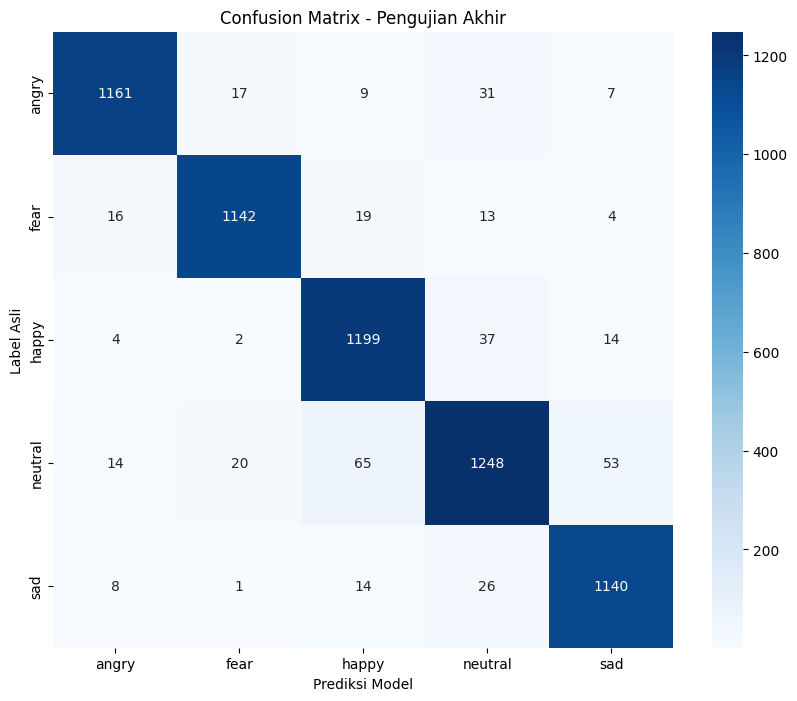

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisasi
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - Pengujian Akhir')
plt.xlabel('Prediksi Model')
plt.ylabel('Label Asli')
plt.show()

# inference

In [26]:
def predict_emotion(text):
    # Preprocessing singkat (pastikan sama dengan preprocessing saat training)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len, padding='post')

    # Prediksi
    pred = model.predict(padded)
    result_idx = np.argmax(pred)
    emotion = le.inverse_transform([result_idx])[0]
    confidence = np.max(pred)

    return emotion, confidence

# Contoh pemakaian
kalimat_baru = "kerja pulang malem, belum ngerjain tugas, rasanya cape tapi takut ngga lulus tepat waktu"
emosi, skor = predict_emotion(kalimat_baru)
print(f"\nKalimat: {kalimat_baru}")
print(f"Hasil Prediksi: {emosi} ({skor*100:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

Kalimat: kerja pulang malem, belum ngerjain tugas, rasanya cape tapi takut ngga lulus tepat waktu
Hasil Prediksi: fear (66.66%)


# saving

In [27]:
# Simpan model dalam format .h5 atau SavedModel
model.save('model_emosi_vitara_v6.h5')
print("Model berhasil disimpan!")

Model berhasil disimpan!


In [28]:
from google.colab import files
files.download('train_data.csv')
files.download('val_data.csv')
files.download('test_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>